In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

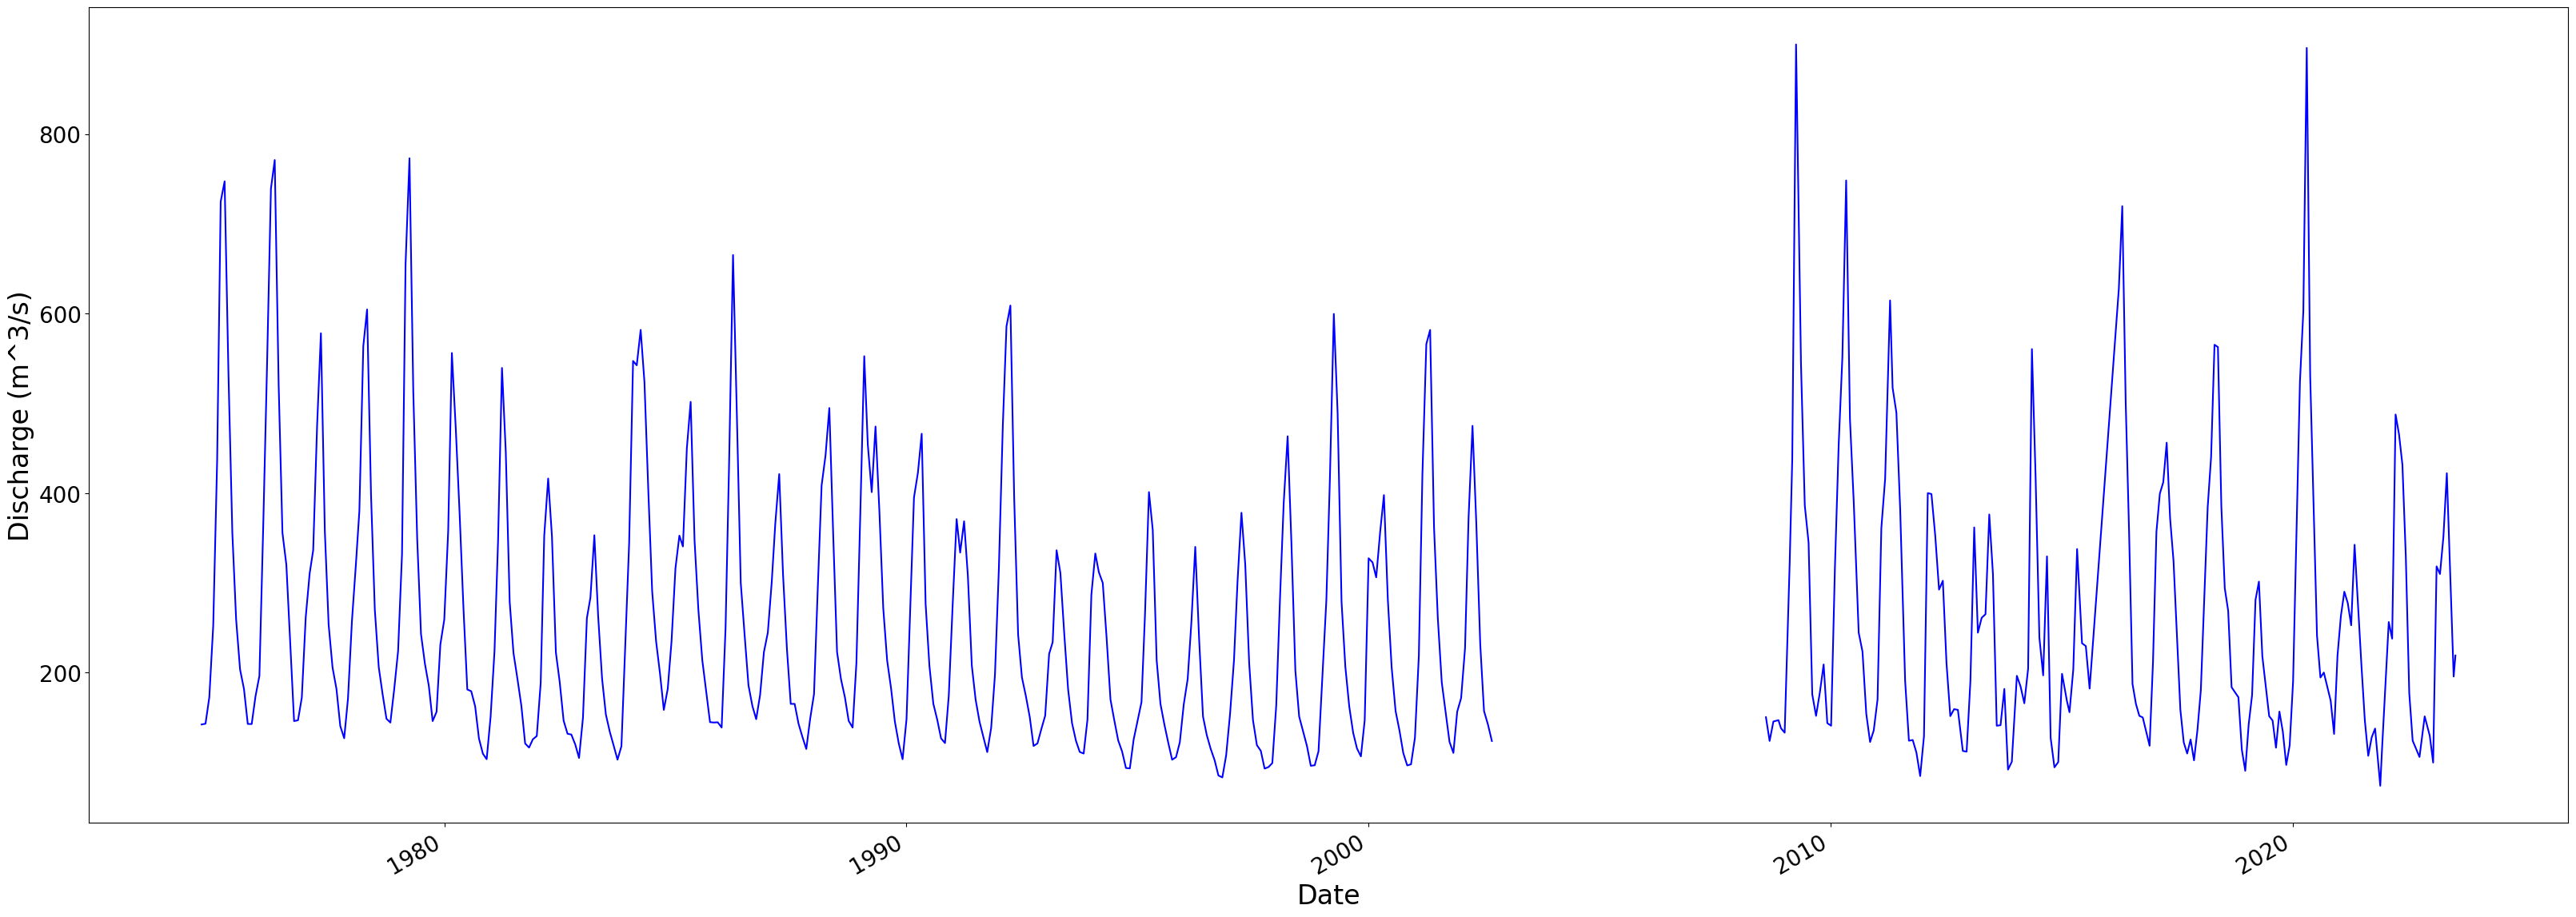

In [2]:
data1 = pd.read_csv("../BEP/data/Discharge data Mohembo 1974-2002.txt", index_col=0, sep="\t", parse_dates=True, 
                    date_format="%Y-%m", comment='#', header=None, names=["Date", "Discharge1974-2002"])
data2 = pd.read_csv("../BEP/data/Discharge data Mohembo 2008-2023.txt", sep=",", comment='#', 
                    header=None, names=["YYYY", "MM", "DD", "Discharge2008-2023", "Error"])
data2["Date"] = pd.to_datetime(dict(year=data2.iloc[:,0], month=data2.iloc[:,1], day=data2.iloc[:,2]))
data2 = data2.drop(columns=["YYYY", "MM", "DD", "Error"])
data2 = data2.set_index("Date")
data1 = data1[data1["Discharge1974-2002"] >= 0]
combined = pd.concat([data1, data2])

fig, ax = plt.subplots(figsize=(40, 15))
combined.plot(ax=ax, color='blue', legend=False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
#plt.axhline(y=355, color='red', linewidth=2);

yearly_max = combined.groupby(combined.index.year).max()
yearly_max = yearly_max.drop([1974, 2008])
#filtered_years1 = yearly_max[(yearly_max["Discharge1974-2002"] > 180) & (yearly_max["Discharge1974-2002"] < 355)]
#filtered_years2 = yearly_max[(yearly_max["Discharge2008-2023"] > 160) & (yearly_max["Discharge2008-2023"] < 355)]
#filtered_years = pd.concat([filtered_years1, filtered_years2])
#filtered_years

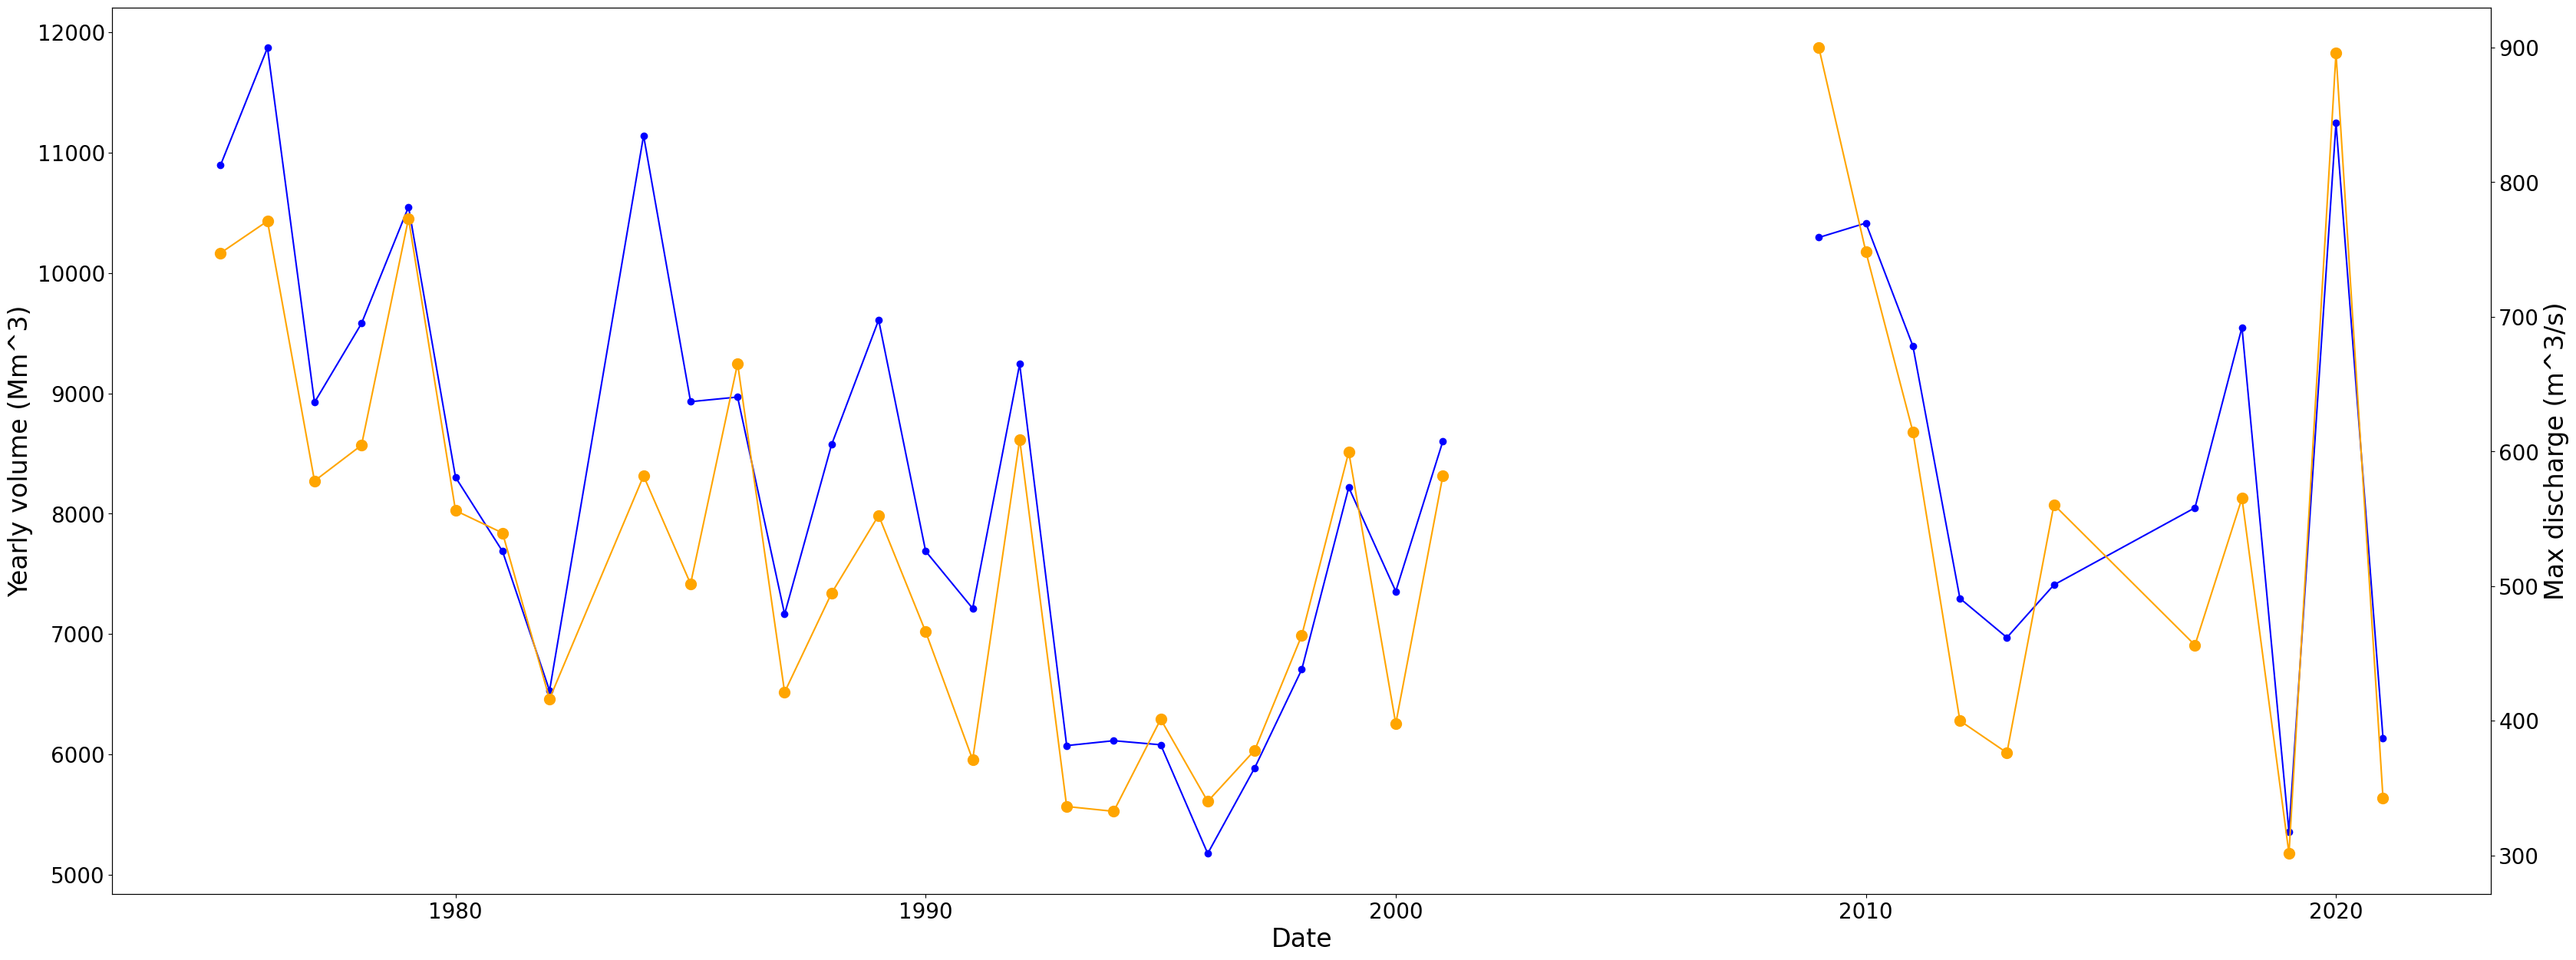

In [3]:
seconds = combined.index.days_in_month * 3600 * 24
vol1 = (combined["Discharge1974-2002"] * seconds).resample("YE").sum() / 1e6
vol2 = (combined["Discharge2008-2023"] * seconds).resample("YE").sum() / 1e6
yearly_volumes = pd.DataFrame({"Volume1974-2002": vol1,"Volume2008-2023": vol2})
yearly_volumes = yearly_volumes.replace(0, np.nan)
count = combined.groupby(combined.index.year).size()
yearly_volumes["N"] = yearly_volumes.index.year.map(count)
yearly_volumes = yearly_volumes[yearly_volumes["N"].notna() & (yearly_volumes["N"] == 12)]
yearly_volumes.index = yearly_volumes.index.year

yearly_max1 = yearly_max.drop([1983, 2002, 2015, 2016, 2022, 2023])

fig, ax = plt.subplots(figsize=(40, 15))
yearly_volumes["Volume1974-2002"].plot(ax=ax, legend=False, color='blue', marker='o')
yearly_volumes["Volume2008-2023"].plot(ax=ax, legend=False, color='blue', marker='o')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.axhline(y=6200, color='purple', linewidth=2)
ax1 = ax.twinx()
yearly_max1.plot(ax=ax1, marker='o', color='orange', legend=False, markersize=10)
#plt.axhline(y=355, color='red', linewidth=2)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Max discharge (m^3/s)", fontsize=24);
#filtered_years3 = yearly_volumes[(yearly_volumes["Volume1974-2002"] < 6200)]
#filtered_years4 = yearly_volumes[(yearly_volumes["Volume2008-2023"] < 6200)]

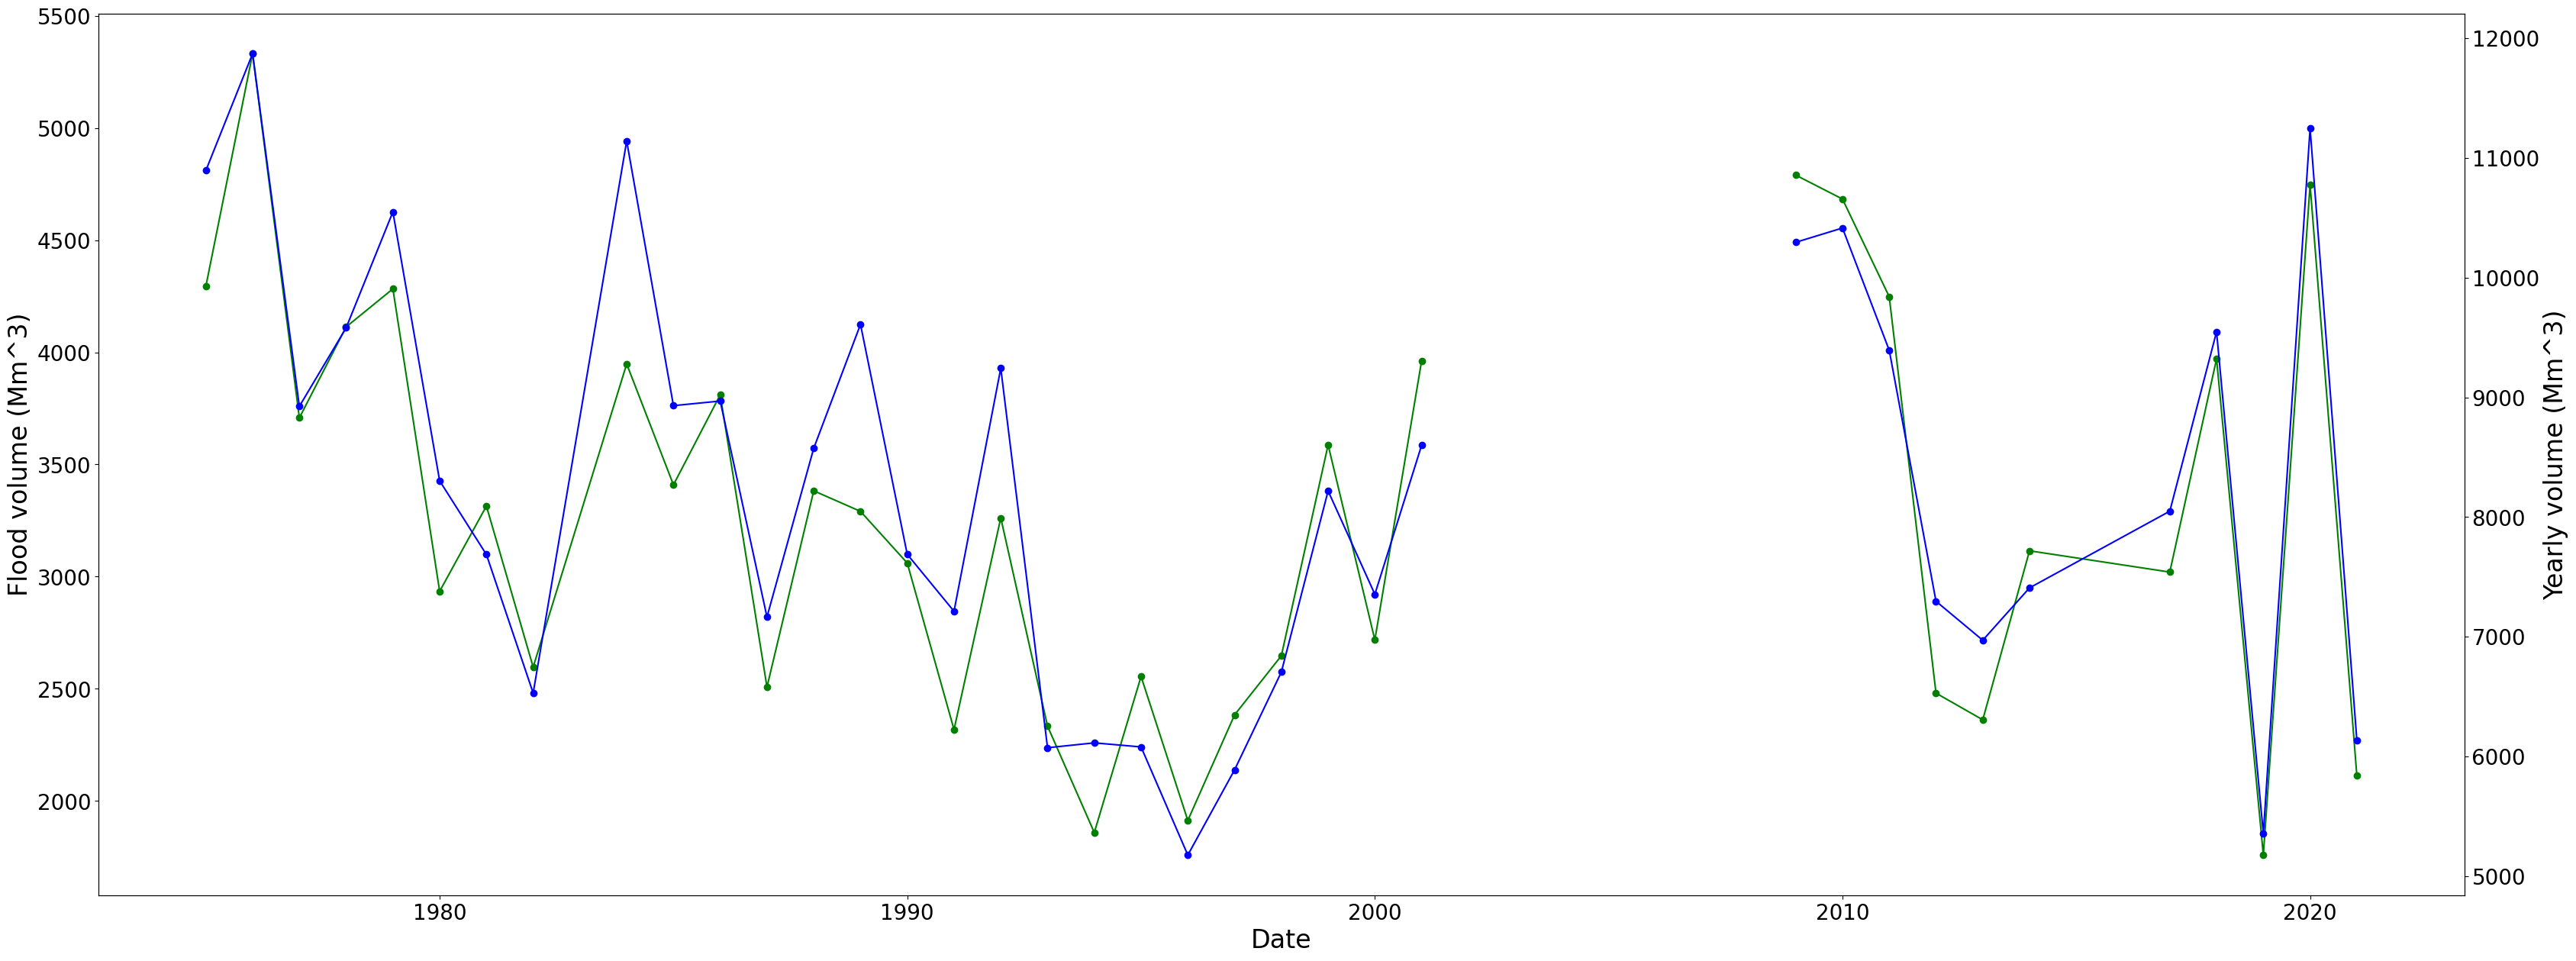

In [6]:
vol3 = (combined["Discharge1974-2002"] * seconds)[combined.index.month.isin([4,5,6])].resample("YE").sum() / 1e6
vol4 = (combined["Discharge2008-2023"] * seconds)[combined.index.month.isin([4,5,6])].resample("YE").sum() / 1e6
flood_volumes = pd.DataFrame({"1974-2002": vol3,"2008-2023": vol4})
flood_volumes = flood_volumes.replace(0, np.nan)
flood_volumes["N"] = flood_volumes.index.year.map(count)
flood_volumes = flood_volumes[flood_volumes["N"].notna() & (flood_volumes["N"] == 12)]
flood_volumes.index = flood_volumes.index.year

fig, ax = plt.subplots(figsize=(40, 15))
flood_volumes["1974-2002"].plot(ax=ax, legend=False, color='green', marker='o')
flood_volumes["2008-2023"].plot(ax=ax, legend=False, color='green', marker='o')
#plt.axhline(y=2350, color='black', linewidth=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax1 = ax.twinx()
yearly_volumes["Volume1974-2002"].plot(ax=ax1, legend=False, color='blue', marker='o')
yearly_volumes["Volume2008-2023"].plot(ax=ax1, legend=False, color='blue', marker='o')
#plt.axhline(y=6200, color='purple', linewidth=2)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Flood volume (Mm^3)", fontsize=24)
ax1.set_ylabel("Yearly volume (Mm^3)", fontsize=24);